In [41]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Queria um desafio então peguei um dataset do kaggle e utilizei os conceitos da aula aplicados a este dataset

In [42]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

df = pd.read_csv(f"{path}/Titanic-Dataset.csv")
# pega os dados do kagglehub

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.shape

(891, 12)

In [45]:
df.isnull().sum()
# vej quantos dados faltantes há

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [46]:
med_age= df['Age'].median()
# pego a mediana de idade
# escolhi a mediana pois as idades sao muito variaveis, menos sensivel a outliers que a media
med_age

28.0

In [47]:
df['Age']=df['Age'].apply(lambda x: med_age if pd.isna(x) else x)
# para cada dado em 'Age' eu verifico se ele é nullo entao preencho com a media se nao for eu deixo como esta

In [48]:
df.isnull().sum()
# verificação se preencheu todos

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
df['Ticket'].value_counts()
# verifico quantos tipos de tickets tem

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64

In [51]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [52]:
df['Embarked']=df['Embarked'].apply(lambda x: 'S' if pd.isna(x) else x)
# como tem somente 2 valores com Nan eu preenco com o valor que mais aprece 'S'

In [53]:
sex = {'male':0,'female':1}
df['Sex'] = df['Sex'].map(sex)
port = {'S':0, 'C':1, 'Q': 2}
df['Embarked'] = df['Embarked'].map(port)
# transformo os dados em numericos

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0


In [55]:
features=df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
# nao escolhi como feture o ID e nome pois nao tem sentido e nem influencia nos outros, Ticket é so o nome da entrada, isso tambem nao influencia, e Cabin podria sim influenciar mas como tem muitos dados faltantes decidi nao usar
target = df['Survived']

In [56]:
x = features
y= target

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [58]:
list_acc = []
for forest in range(10,101,10):
    model = RandomForestClassifier(n_estimators=forest)
    # o parametro escolhido ajuda no overfitting e decide quando arvores serao usadas, random state garante a mesma seed para cada rodada
    model = model.fit(x_train,y_train)
    # treina o modelo com quantidades diferentes de arvores
    predict = model.predict(x_test)
    # faz predição
    acc = accuracy_score(y_test,predict)
    # compara os dois tests e faz uma acuracia 
    list_acc.append(acc)

In [59]:
list_acc

[0.8171641791044776,
 0.7985074626865671,
 0.8246268656716418,
 0.8171641791044776,
 0.8097014925373134,
 0.8134328358208955,
 0.8171641791044776,
 0.8171641791044776,
 0.8022388059701493,
 0.8097014925373134]

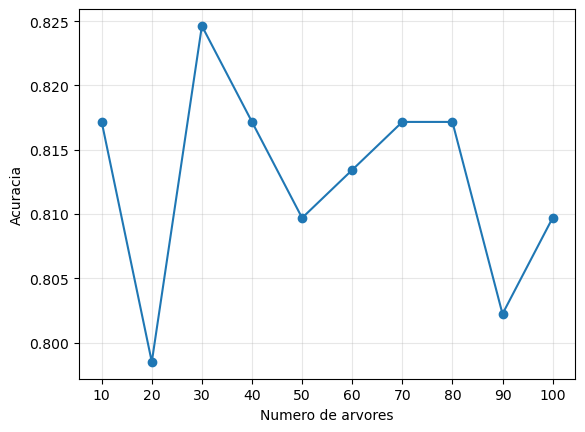

In [60]:
plt.plot(range(10,101,10), list_acc, marker='o')
plt.xticks(range(10,101,10))
plt.xlabel("Numero de arvores")
plt.ylabel("Acuracia")
plt.grid(alpha=0.3)
plt.savefig("random_forest_estimators.png", dpi=150)
plt.show()

### Conclusão: As features selecionadas obtiveram uma acuracia ok para os testes com diferentes quantidades de arvores. O melhor resultado foi com 30 arvores com acuracia de 0.8246268656716418. Nisso o modelo pode prever 82% dos dados de teste, para melhoria pode-se aumentar o dataset para obter mais dados diversificados.